In [72]:
#https://scanpy.readthedocs.io/en/latest/tutorials/basics/clustering-2017.html

In [73]:
%pip install scanpy

Note: you may need to restart the kernel to use updated packages.


In [74]:
from __future__ import annotations
import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc

In [75]:
sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.set_figure_params(dpi=80, facecolor="white")
sc.logging.print_header()

/opt/anaconda3/lib/python3.13/site-packages/session_info2/__init__.py:133: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  and (v := getattr(pkg, "__version__", None))


Package,Version
anndata,0.12.13
matplotlib,3.10.6
pandas,2.3.3
scanpy,1.12.1
numpy,2.3.5
Component,Info
Python,"3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:11:29) [Clang 20.1.8 ]"
OS,macOS-14.6-arm64-arm-64bit-Mach-O
CPU,"8/8 logical CPU cores, arm"
GPU,No GPU found


In [76]:
results_file = "write/pbmc3k.h5ad"  # the file that will store the analysis results

In [77]:
adata = sc.read_10x_mtx(
    "data/filtered_gene_bc_matrices/hg19/",  # the directory with the `.mtx` file
    var_names="gene_symbols",  # use gene symbols for the variable names (variables-axis index)
    cache=True,  # write a cache file for faster subsequent reading
)

... reading from cache file cache/data-filtered_gene_bc_matrices-hg19-matrix.h5ad


In [78]:
adata

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

In [79]:
adata.var_names_make_unique()  # this is unnecessary if using `var_names='gene_ids'` in `sc.read_10x_mtx`

In [80]:
adata

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

normalizing counts per cell
    finished (0:00:00)


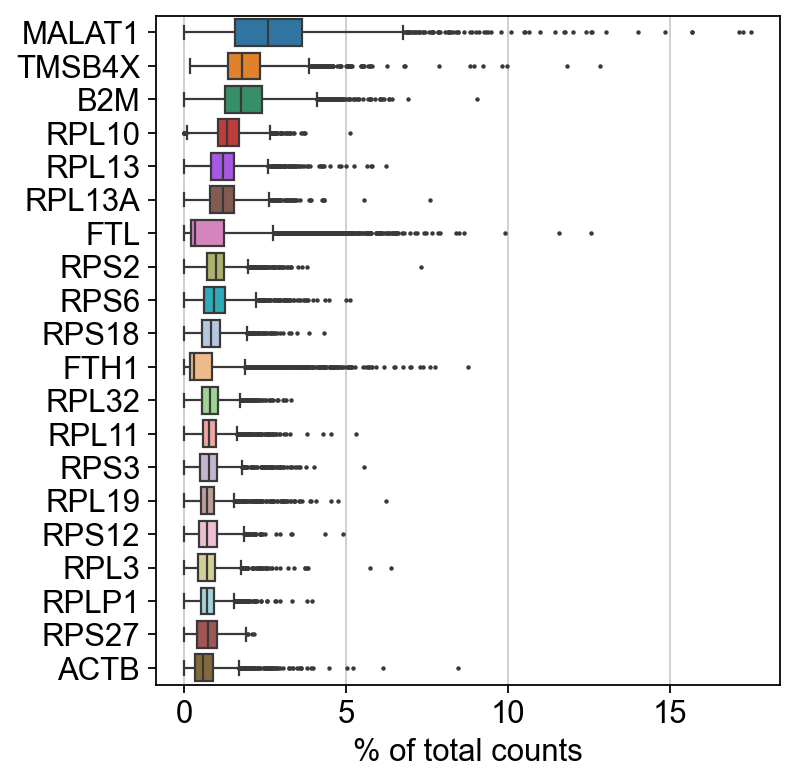

In [81]:
sc.pl.highest_expr_genes(adata, n_top=20)

In [82]:
sc.pp.filter_cells(adata, min_genes=200)  # this does nothing, in this specific case
sc.pp.filter_genes(adata, min_cells=3)
adata

filtered out 19024 genes that are detected in less than 3 cells


AnnData object with n_obs × n_vars = 2700 × 13714
    obs: 'n_genes'
    var: 'gene_ids', 'n_cells'

In [83]:
# annotate the group of mitochondrial genes as "mt"
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)

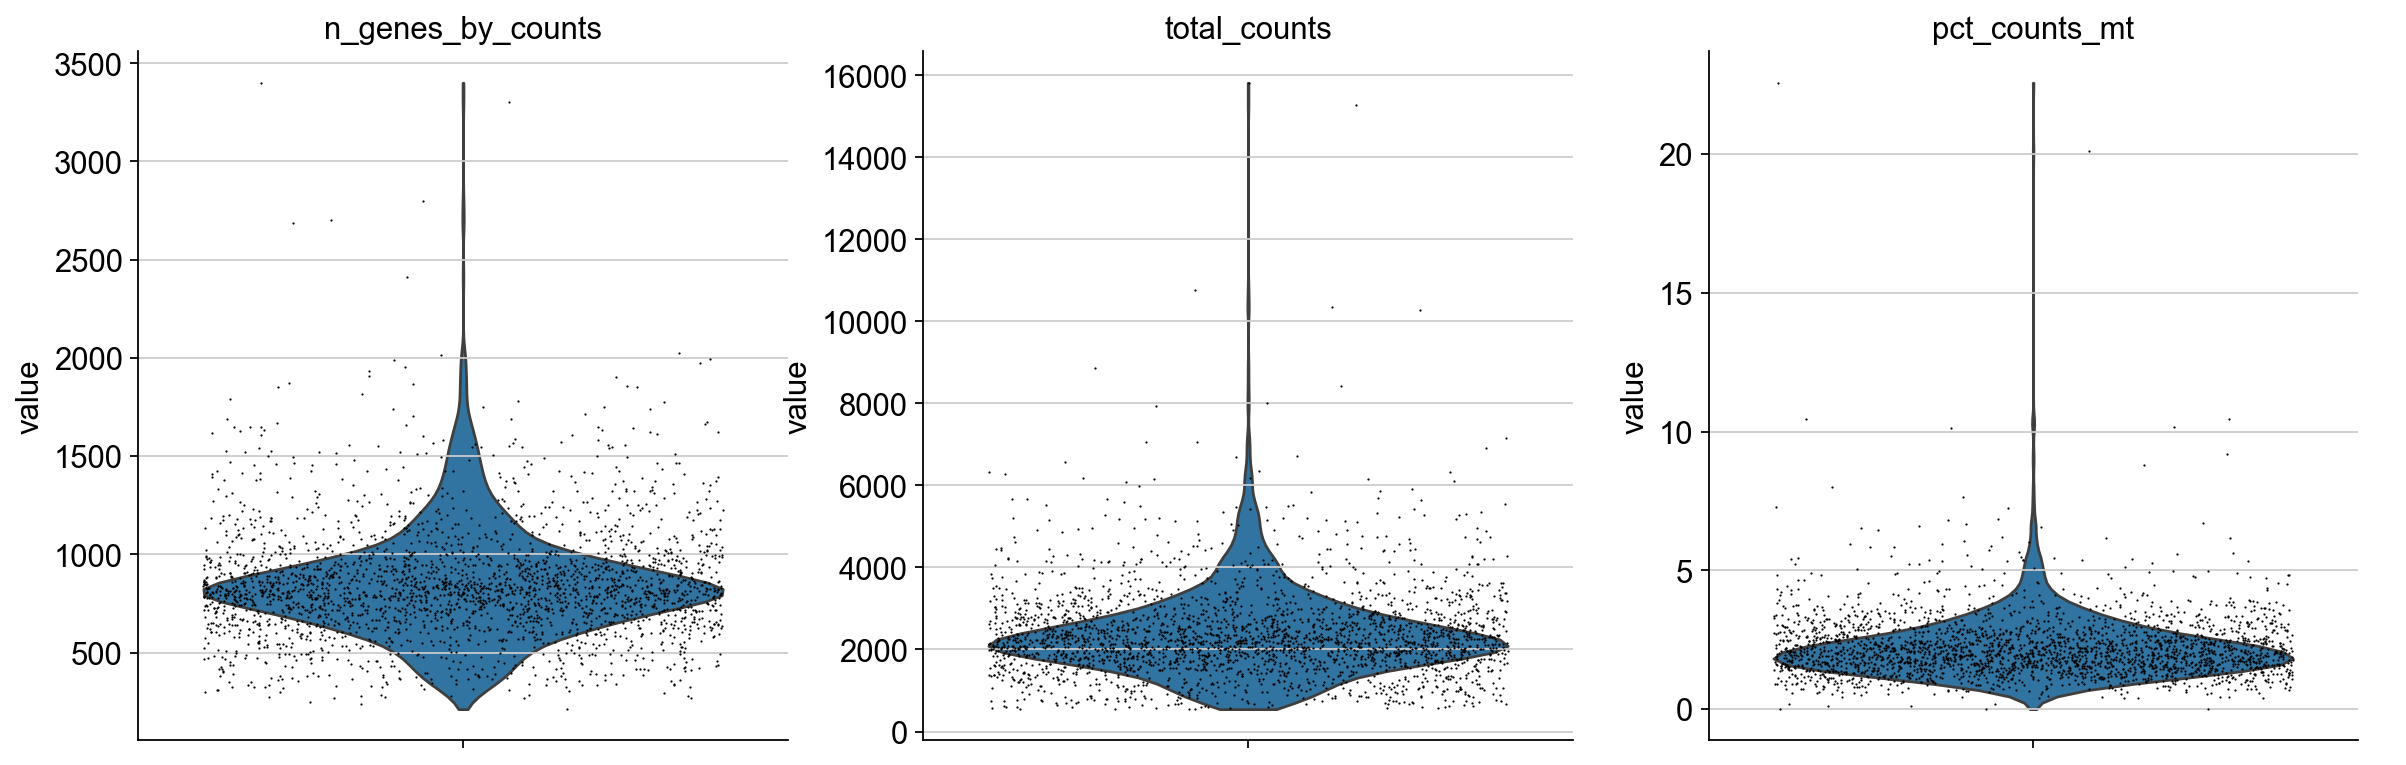

In [84]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

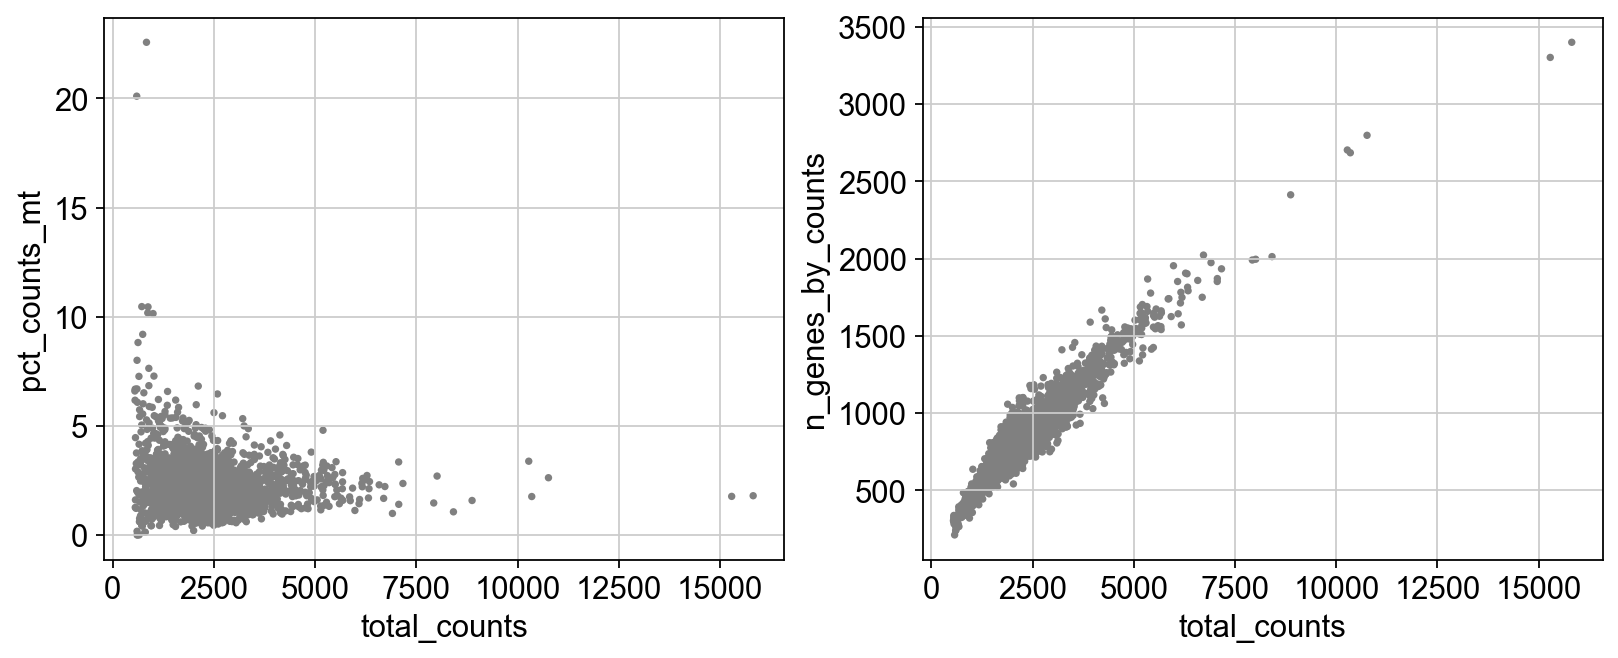

In [85]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")
sc.pl.scatter(adata, x="total_counts", y="pct_counts_mt", show=False, ax=axs[0])
sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts", show=False, ax=axs[1]);

In [86]:
adata = adata[
    (adata.obs.n_genes_by_counts < 2500) & (adata.obs.n_genes_by_counts > 200) & (adata.obs.pct_counts_mt < 5),
    :,
].copy()
adata.layers["counts"] = adata.X.copy()

In [87]:
adata

AnnData object with n_obs × n_vars = 2638 × 13714
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    layers: 'counts'

In [88]:
sc.pp.normalize_total(adata, target_sum=1e4)

normalizing counts per cell
    finished (0:00:00)


In [89]:
sc.pp.log1p(adata)

In [90]:
%pip install scikit-misc

Note: you may need to restart the kernel to use updated packages.


In [91]:
sc.pp.highly_variable_genes(
    adata,
    layer="counts",
    n_top_genes=2000,
    min_mean=0.0125,
    max_mean=3,
    min_disp=0.5,
    flavor="seurat_v3",
)

extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)


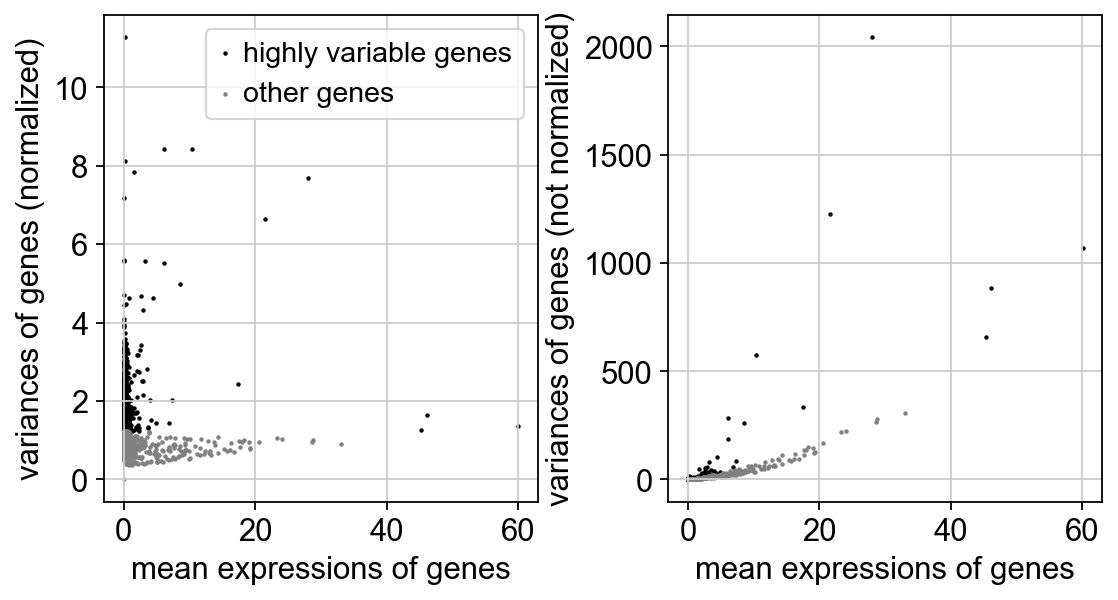

In [92]:
sc.pl.highly_variable_genes(adata)

In [93]:
adata.layers["scaled"] = adata.X.toarray()
sc.pp.regress_out(adata, ["total_counts", "pct_counts_mt"], layer="scaled")
sc.pp.scale(adata, max_value=10, layer="scaled")

regressing out ['total_counts', 'pct_counts_mt']
    finished (0:00:00)


In [94]:
#Principle component analysis

In [95]:
sc.pp.pca(adata, layer="scaled", svd_solver="arpack")

computing PCA
    with n_comps=50
    finished (0:00:00)


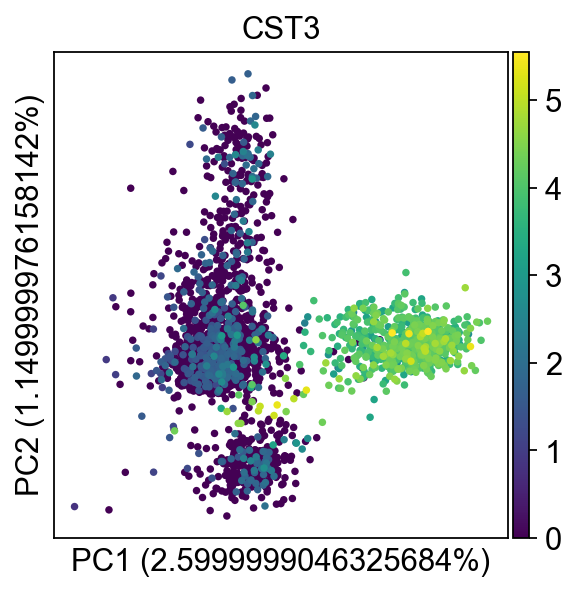

In [96]:
sc.pl.pca(adata, annotate_var_explained=True, color="CST3")

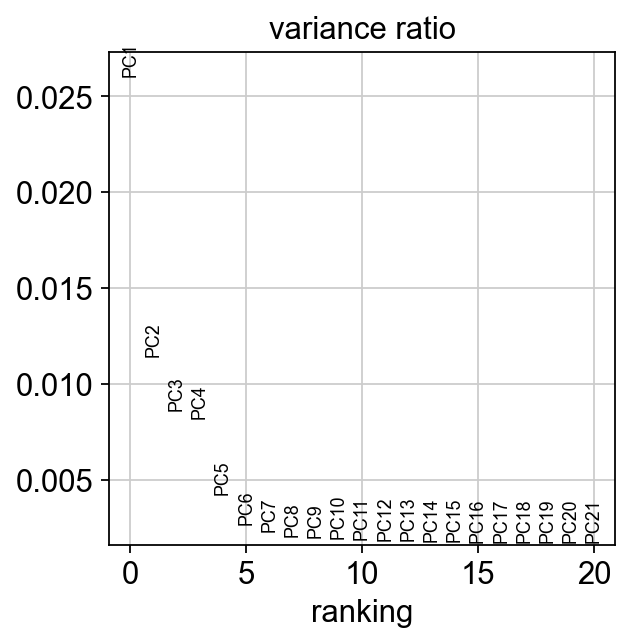

In [97]:
sc.pl.pca_variance_ratio(adata, n_pcs=20)

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8942 (\N{VERTICAL ELLIPSIS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


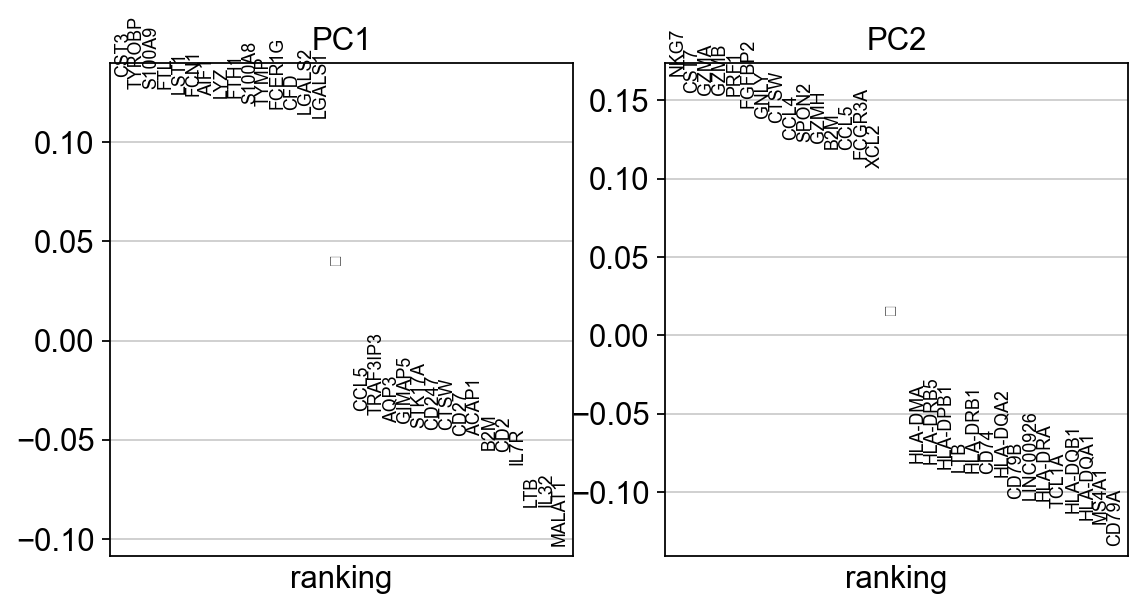

In [98]:
sc.pl.pca_loadings(adata, components=(1, 2), include_lowest=True)

In [99]:
#Computing the neighbourhood graph

In [100]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

computing neighbors
    using 'X_pca' with n_pcs = 40
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)


In [101]:
#Embedding the neighborhood graph

In [102]:
%pip install 'scanpy[leiden]'

Note: you may need to restart the kernel to use updated packages.


In [103]:
sc.tl.leiden(adata)

running Leiden clustering


/var/folders/mg/82fy80716n554vlypj97_2f80000gn/T/ipykernel_25373/3467744858.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata)


    finished: found 10 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


In [104]:
sc.tl.paga(adata)
sc.pl.paga(adata, plot=False)  # remove `plot=False` if you want to see the coarse-grained graph
sc.tl.umap(adata, init_pos='paga')

running PAGA
    finished: added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns) (0:00:00)
--> added 'pos', the PAGA positions (adata.uns['paga'])
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:01)


In [105]:
sc.tl.umap(adata)

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:01)


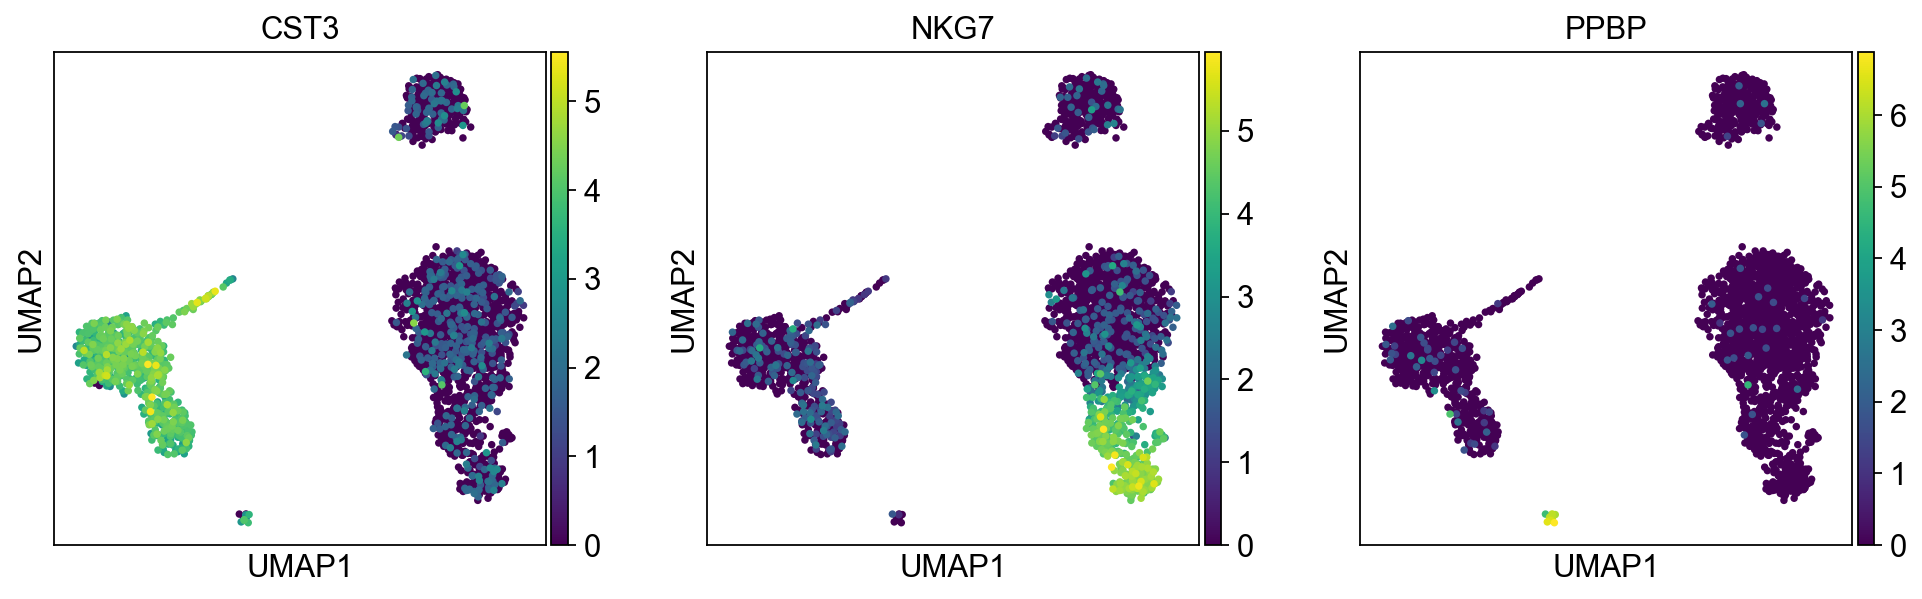

In [106]:
sc.pl.umap(adata, color=["CST3", "NKG7", "PPBP"])

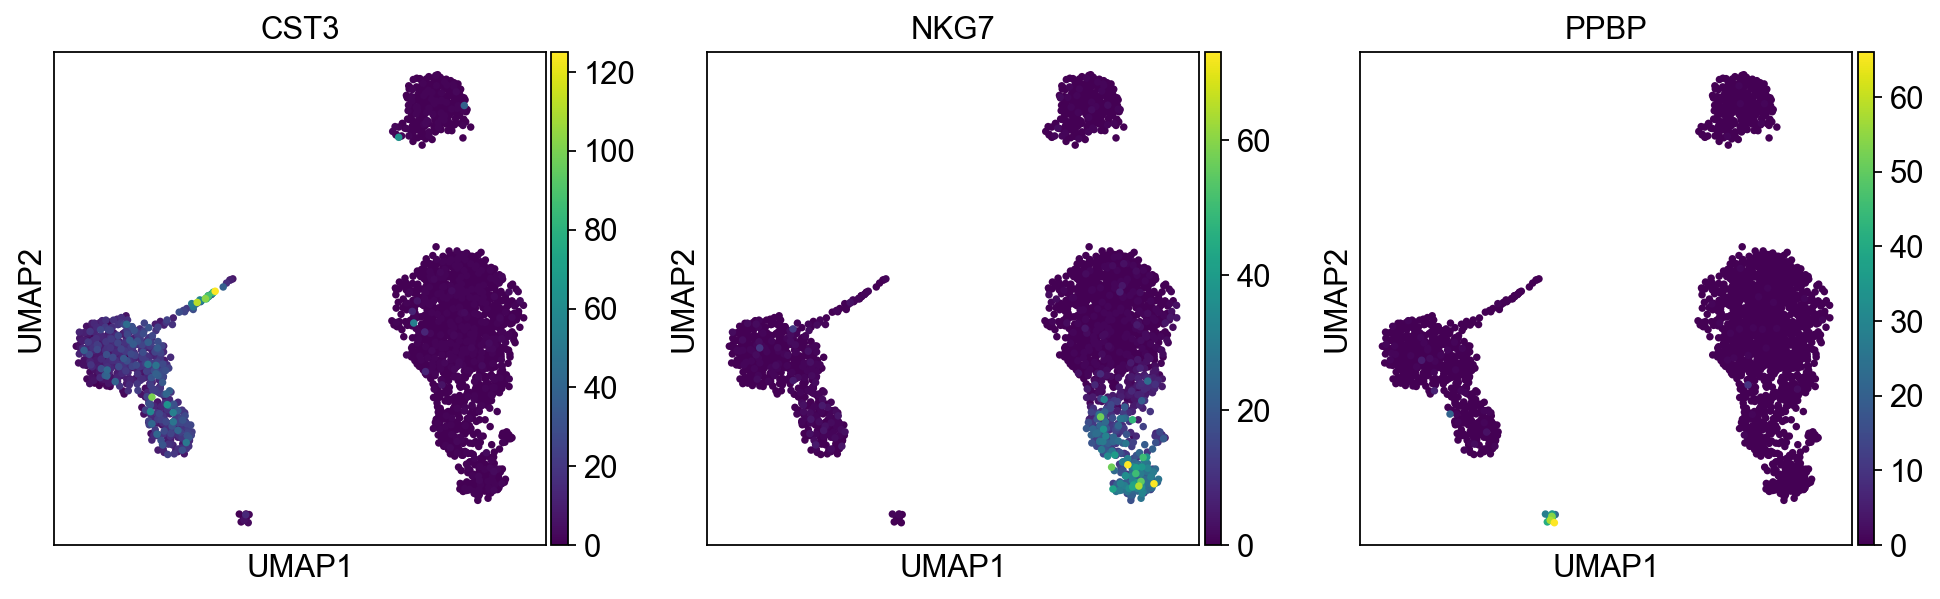

In [107]:
sc.pl.umap(adata, color=["CST3", "NKG7", "PPBP"], layer="counts")

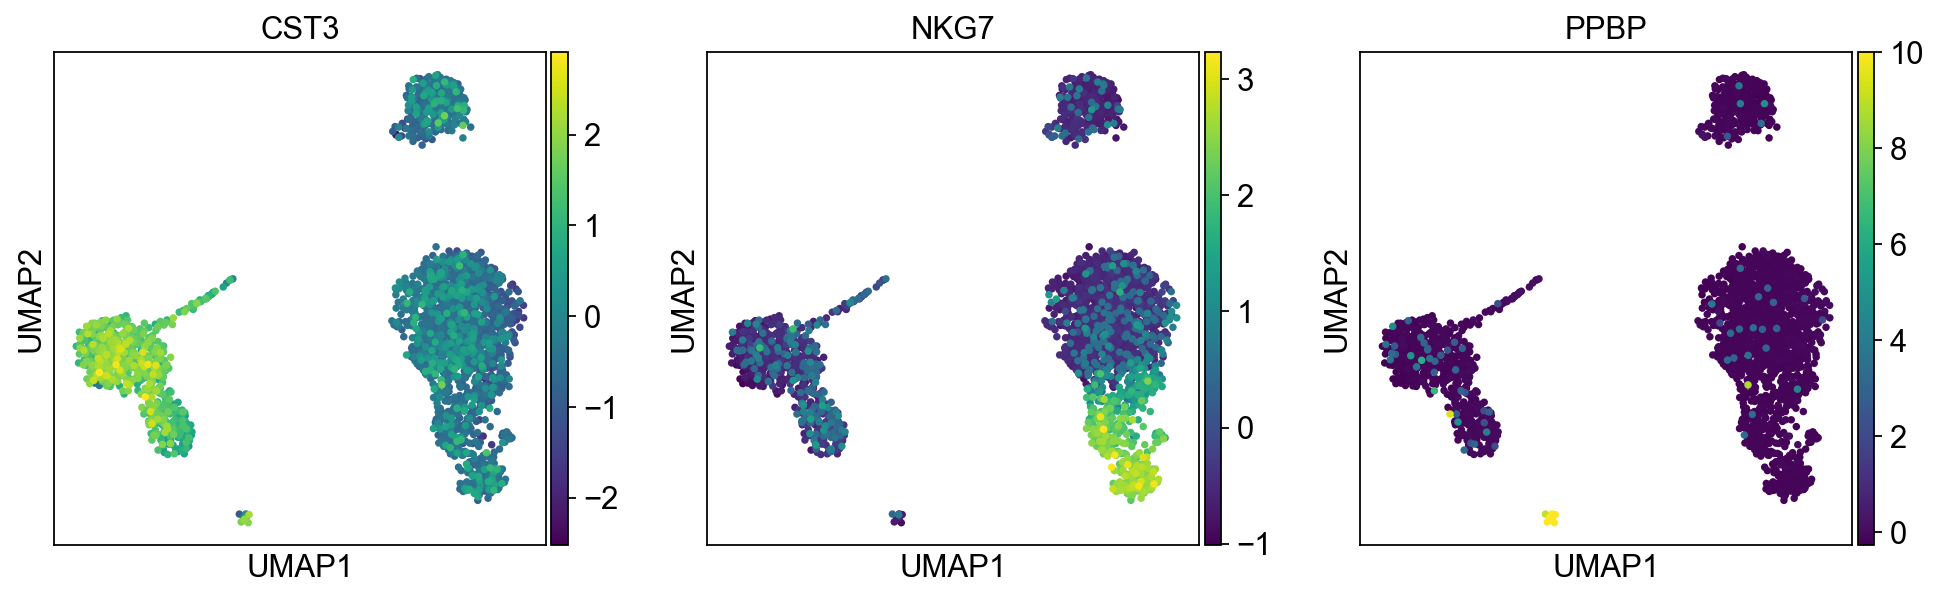

In [108]:
sc.pl.umap(adata, color=["CST3", "NKG7", "PPBP"], layer="scaled")

In [109]:
sc.tl.leiden(
    adata,
    resolution=0.7,
    random_state=0,
    flavor="igraph",
    n_iterations=2,
    directed=False,
)
adata.obs["leiden"] = adata.obs["leiden"].copy()
adata.uns["leiden"] = adata.uns["leiden"].copy()
adata.obsm["X_umap"] = adata.obsm["X_umap"].copy()

running Leiden clustering
    finished: found 8 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


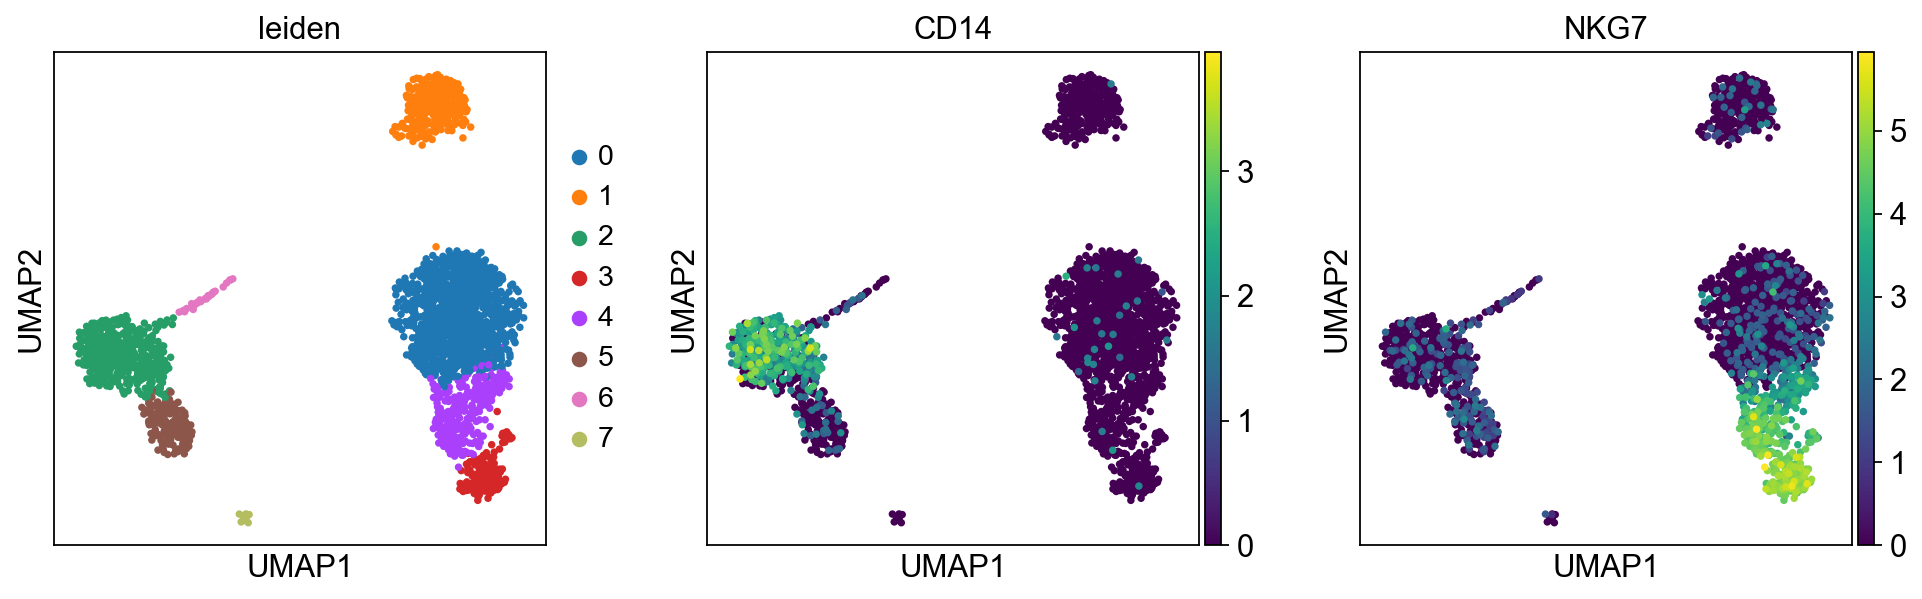

In [110]:
sc.pl.umap(adata, color=["leiden", "CD14", "NKG7"])

In [111]:
#Finding marker genes

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


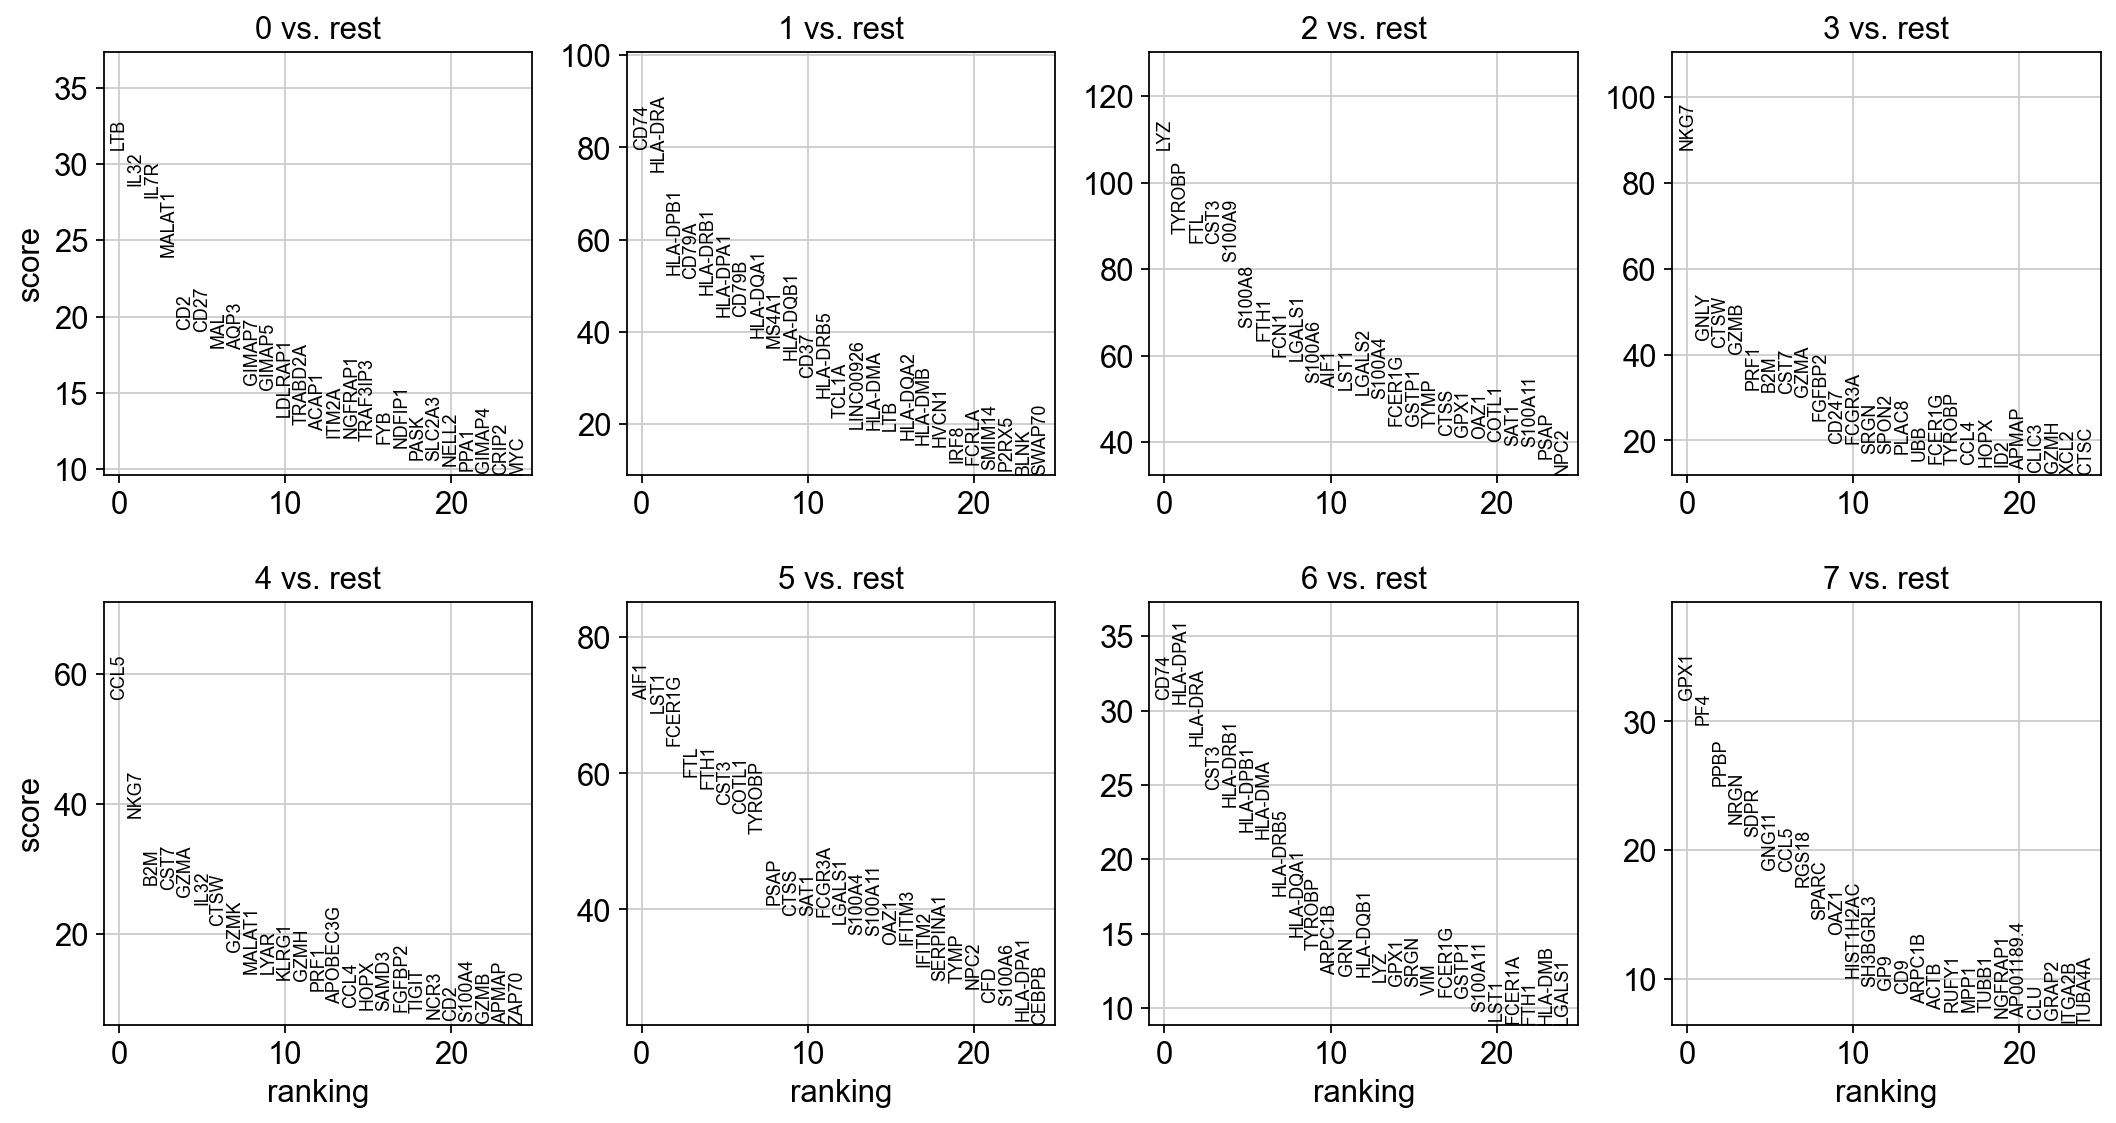

In [112]:
sc.tl.rank_genes_groups(adata, "leiden", mask_var="highly_variable", method="t-test")
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

In [113]:
sc.settings.verbosity = 2  # reduce the verbosity

ranking genes
    finished (0:00:00)


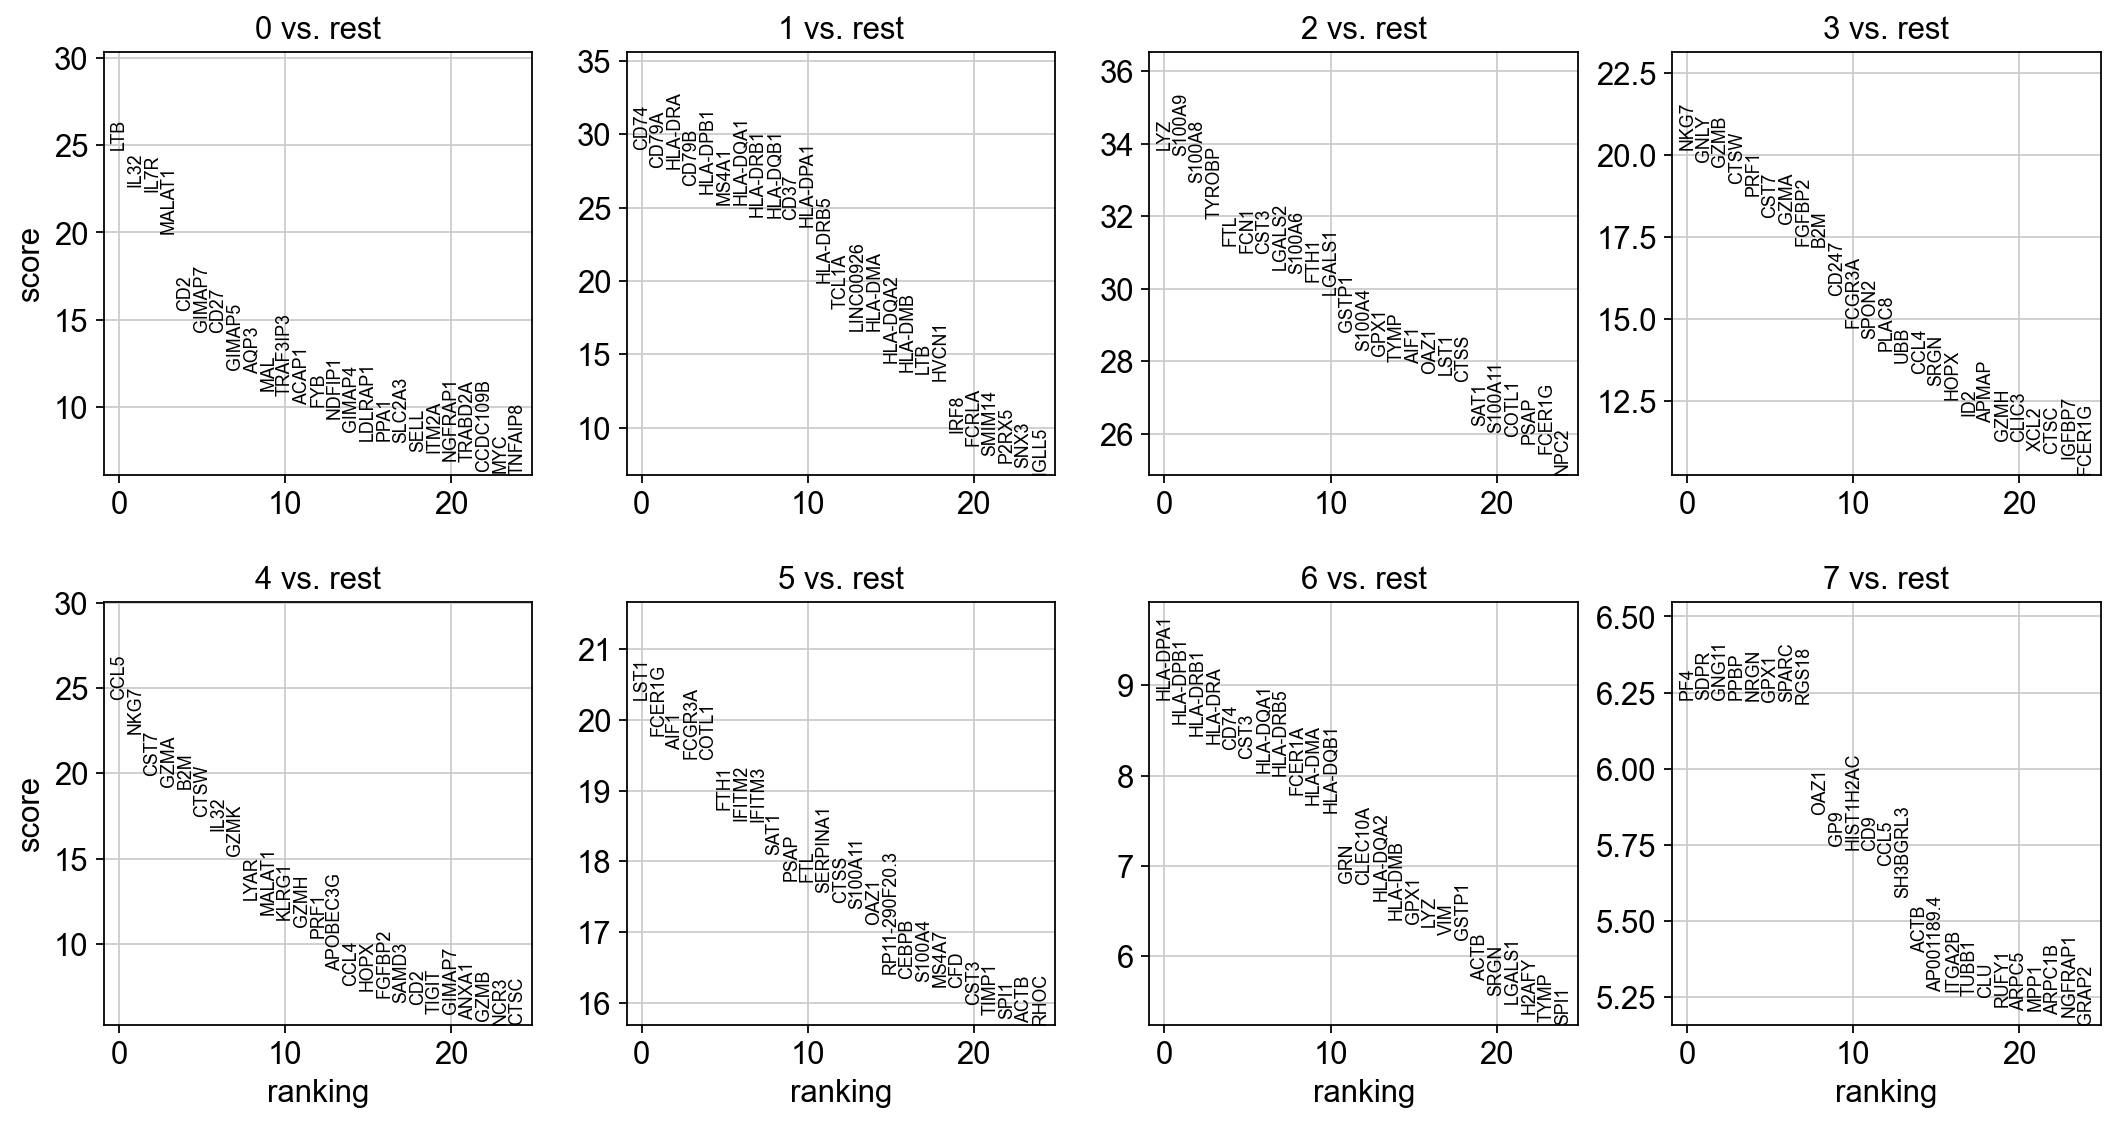

In [114]:
sc.tl.rank_genes_groups(adata, "leiden", mask_var="highly_variable", method="wilcoxon")
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

In [115]:
adata.write(results_file)

ranking genes
    finished (0:00:00)


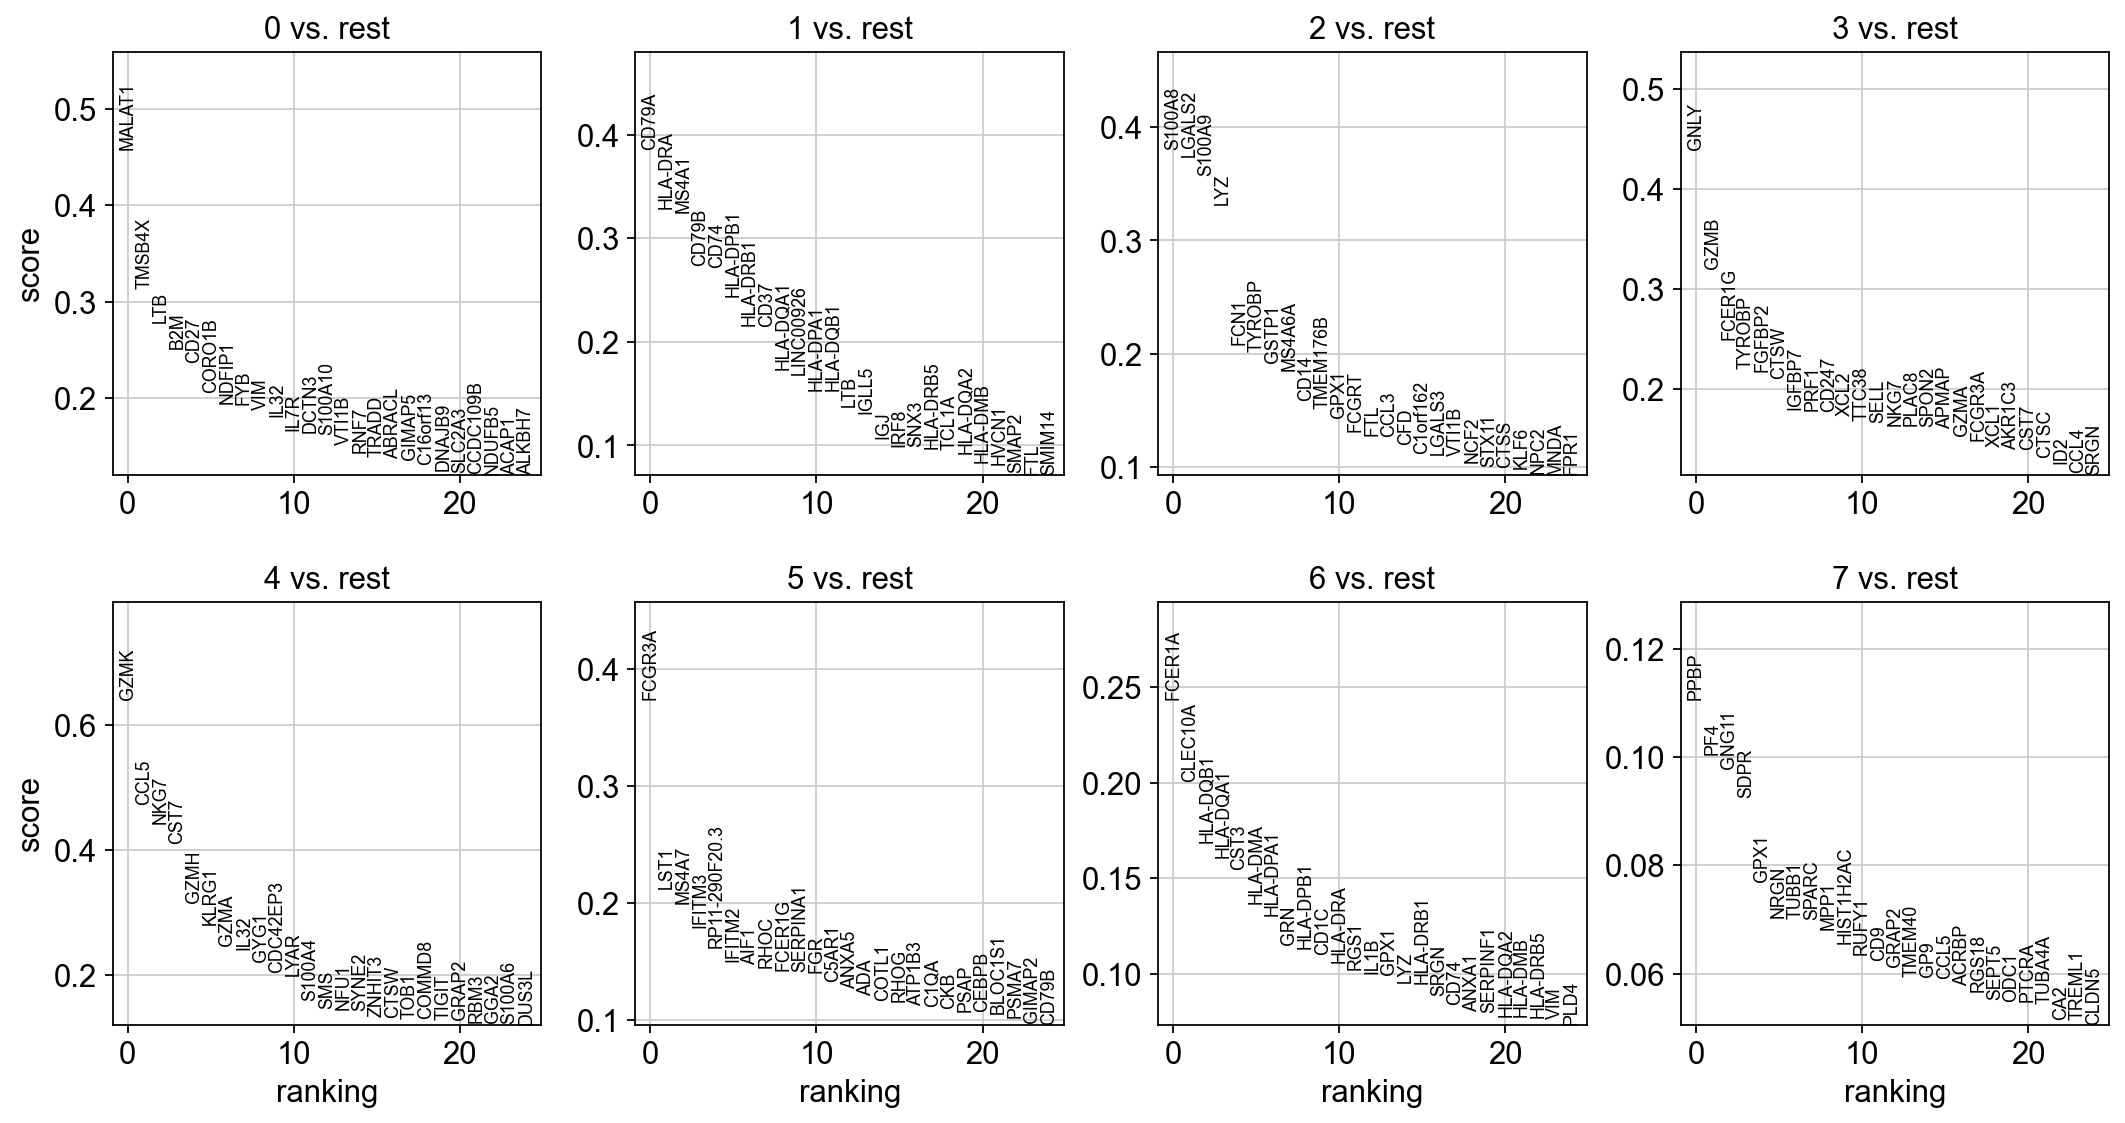

In [116]:
sc.tl.rank_genes_groups(adata, "leiden", mask_var="highly_variable", method="logreg", max_iter=1000)
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

In [117]:
marker_genes = [
    *["IL7R", "CD79A", "MS4A1", "CD8A", "CD8B", "LYZ", "CD14"],
    *["LGALS3", "S100A8", "GNLY", "NKG7", "KLRB1"],
    *["FCGR3A", "MS4A7", "FCER1A", "CST3", "PPBP"],
]

In [118]:
adata = sc.read(results_file)

In [119]:
pd.DataFrame(adata.uns["rank_genes_groups"]["names"]).head(5)

,0,1,2,3,4,5,6,7
0,LTB,CD74,LYZ,NKG7,CCL5,LST1,HLA-DPA1,PF4
1,IL32,CD79A,S100A9,GNLY,NKG7,FCER1G,HLA-DPB1,SDPR
2,IL7R,HLA-DRA,S100A8,GZMB,CST7,AIF1,HLA-DRB1,GNG11
3,MALAT1,CD79B,TYROBP,CTSW,GZMA,FCGR3A,HLA-DRA,PPBP
4,CD2,HLA-DPB1,FTL,PRF1,B2M,COTL1,CD74,NRGN


In [120]:
result = adata.uns["rank_genes_groups"]
groups = result["names"].dtype.names
pd.DataFrame({f"{group}_{key[:1]}": result[key][group] for group in groups for key in ["names", "pvals"]}).head(5)

,0_n,0_p,1_n,1_p,2_n,2_p,3_n,3_p,4_n,4_p,5_n,5_p,6_n,6_p,7_n,7_p
0,LTB,2.233887e-135,CD74,1.972305e-184,LYZ,5.016654e-251,NKG7,1.695005e-90,CCL5,5.538259e-131,LST1,1.472603e-91,HLA-DPA1,9.083160e-19,PF4,4.722886e-10
1,IL32,2.122117e-113,CD79A,1.882747e-169,S100A9,1.126831e-248,GNLY,2.091409e-87,NKG7,8.555412e-111,FCER1G,4.577206e-87,HLA-DPB1,1.012875e-17,SDPR,4.733899e-10
2,IL7R,6.540003e-111,HLA-DRA,2.840744e-168,S100A8,6.457752e-238,GZMB,4.301595e-86,CST7,5.979875e-88,AIF1,2.463548e-85,HLA-DRB1,3.140833e-17,GNG11,4.733899e-10
3,MALAT1,2.310542e-88,CD79B,1.868216e-154,TYROBP,1.259221e-223,CTSW,1.453698e-81,GZMA,1.252633e-82,FCGR3A,2.609486e-84,HLA-DRA,6.528837e-17,PPBP,4.744938e-10
4,CD2,2.947014e-54,HLA-DPB1,3.333386e-148,FTL,1.887168e-213,PRF1,1.647940e-78,B2M,1.363322e-81,COTL1,3.772454e-84,CD74,1.090345e-16,NRGN,4.800511e-10


ranking genes
    finished (0:00:00)


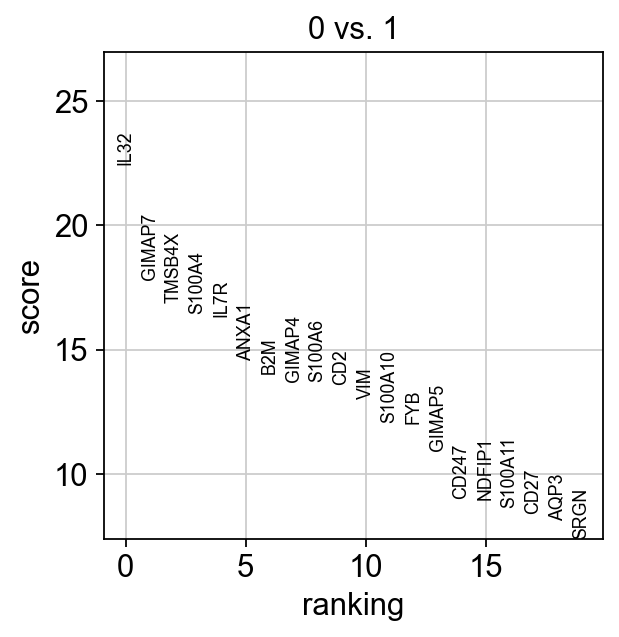

In [121]:
sc.tl.rank_genes_groups(
    adata,
    "leiden",
    mask_var="highly_variable",
    groups=["0"],
    reference="1",
    method="wilcoxon",
)
sc.pl.rank_genes_groups(adata, groups=["0"], n_genes=20)

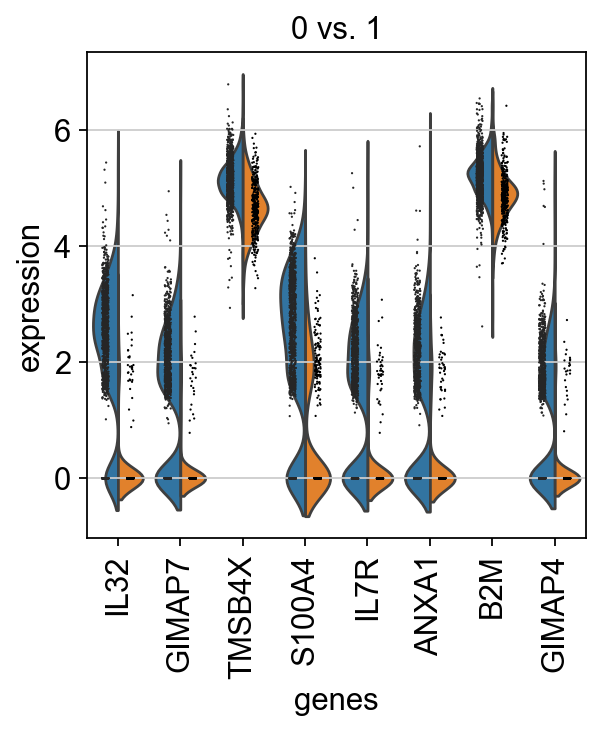

In [122]:
sc.pl.rank_genes_groups_violin(adata, groups="0", n_genes=8)

In [123]:
adata = sc.read(results_file)

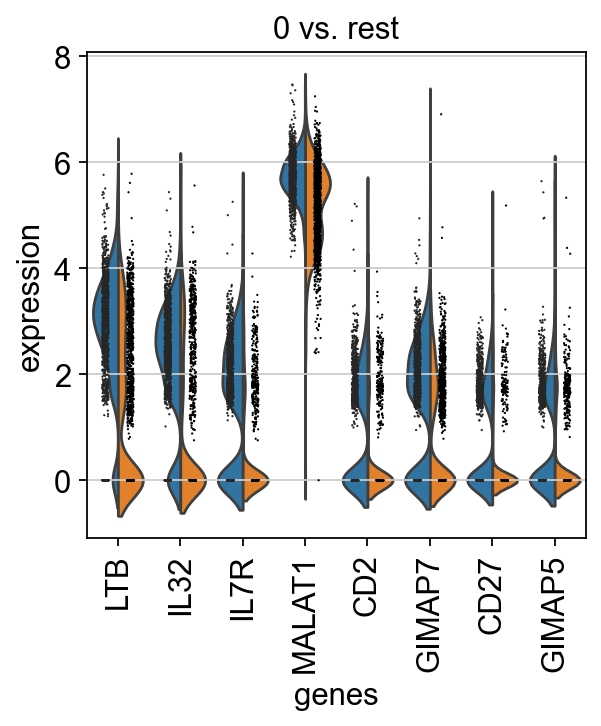

In [124]:
sc.pl.rank_genes_groups_violin(adata, groups="0", n_genes=8)

In [125]:
new_cluster_names = [
    "CD4 T",
    "B",
    "CD14+ Monocytes",
    "NK",
    "CD8 T",
    "FCGR3A+ Monocytes",
    "Dendritic",
    "Megakaryocytes",
]
adata.rename_categories("leiden", new_cluster_names)

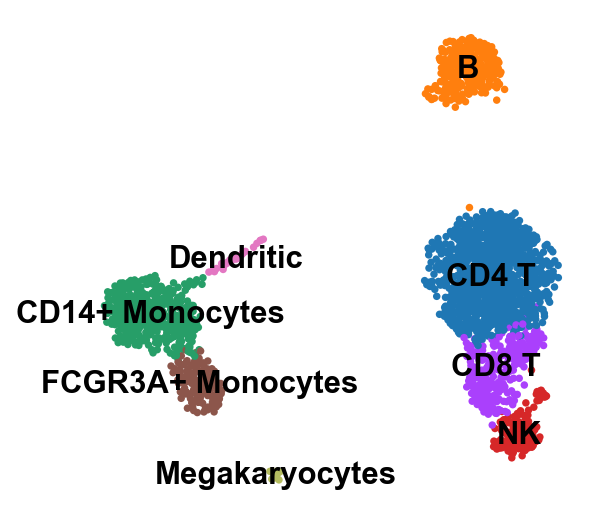

In [126]:
sc.pl.umap(adata, color="leiden", legend_loc="on data", title="", frameon=False)

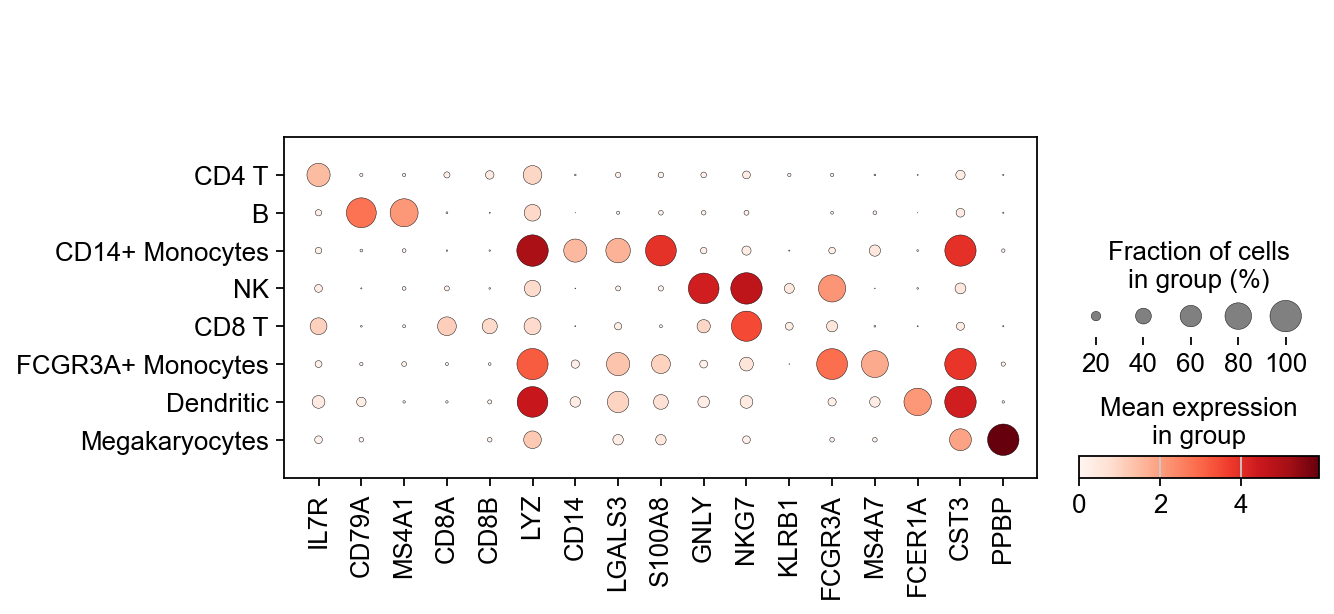

In [127]:
sc.pl.dotplot(adata, marker_genes, groupby="leiden")

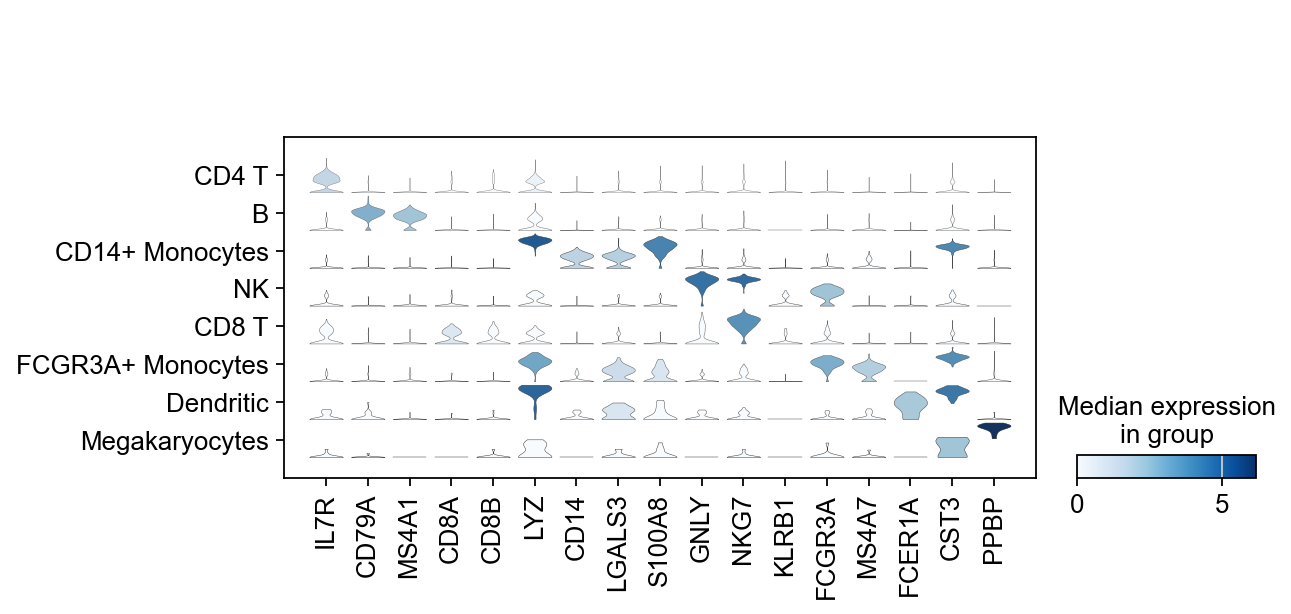

In [128]:
sc.pl.stacked_violin(adata, marker_genes, groupby="leiden")

In [129]:
adata

AnnData object with n_obs × n_vars = 2638 × 13714
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'hvg', 'leiden', 'leiden_colors', 'leiden_sizes', 'log1p', 'neighbors', 'paga', 'pca', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'scaled'
    obsp: 'connectivities', 'distances'